# Battery sizing across five households and four GEN-I price lists

Perfect-foresight (MILP) annual electricity cost for **five Fluvius households**, solved once
per **battery capacity** and once per **tariff**, over the **whole 2024 calendar year**
(35 136 fifteen-minute intervals, leap year included). Every solve uses the *continuous*
formulation (`use_discrete_actions=False`), so each point is the theoretical optimum for that
(household, tariff, capacity) — no controller can do better.

## The four tariffs

All five households own a PV self-supply device, so all four price lists are the
*samooskrba* (self-supply) variants and every solve runs under `pricing_scheme="si_samooskrba"`
— intra-interval netting of PV against load, with only the residual metered.

| Plan | `paket_id` | Import price [EUR/kWh] | Export credit [EUR/kWh] | Monthly fee |
|---|---|---|---|---|
| GEN-I Dinamični | `GENI_SAMO_DINAMICNI` | SIPX + 0.01199 | SIPX − 0.01199, per interval | 1.97 |
| GEN-I Redni | `GENI_SAMO_REDNI` | 0.10290 flat (ET) | 0.05390 flat, per interval | 0.99 |
| GEN-I Aktivni | `GENI_SAMO_AKTIVNI` | 4 blocks, 0.04090 → 0.19290 | 4 blocks, 0.00190 → 0.14990 | 0.99 |
| GEN-I Redni + NET metering | `GENI_NETMETERING` | 0.12990 flat (ET) | **nothing per interval** — netted annually | 0.99 |

(Monthly fees are the `mesecno_nadomestilo_eko` rates: `eko_racun=True` is the pricing
default, so the dynamic list carries about 12 EUR/a more in fixed supplier fee than the other
three.) Beyond that, all four add the same network charge, levies and VAT on the metered
offtake and the same ratchet excess-power charge, so what separates them is the supplier's
energy price and the way exported energy is credited.

**NET metering needs an annual settlement, not an interval one.** `si_obracun._cena_oddaje`
returns `0.0` for `TipOdkupa.NET_METERING`, which is correct at the interval level — that
contract credits nothing as you export, it nets exports against imports once a year, on the
*supplier energy* component only (network charges and levies stay on gross metered offtake
under the 2024 network act). Priced interval-by-interval it would look absurdly bad and the
solver would curtail rather than export. `run_milp_benchmark` therefore takes
`annual_netting_rate_eur_per_kwh`, which adds

    credit = rate * min(total imported, total exported)

to the objective as a single bounded variable, and books it on the closing interval — see the
`Netting_Credit_EUR` column. `rate` is the list's own VAT-inclusive ET price, read straight
off `PAKETI["GENI_NETMETERING"]`.

## What is new relative to the single-household version

* Five households instead of one, selected from the four PV Fluvius families by a documented
  rule rather than by hand.
* Four tariffs per household instead of one, with the NET-metering settlement above.
* **ROI**: capex, NPV, discounted ROI %, IRR and simple payback for every point on every curve.
* **Cycle count**: equivalent full cycles measured on the *stored* energy, and used to derive a
  cycle-limited service life that feeds back into the ROI.
* An explicit whole-year audit (section 4) — the horizon really is every interval of 2024.

In [1]:
### Imports
import json
import math
import sys
import time
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import pulp
from joblib import Parallel, delayed
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter

import importlib
import Data_Loader as dl
import Environment as environment_module
import Horizon_Comparison as hc
import MILP_Benchmark as milp_module
import Pricing_Functions as pricing_module

dl = importlib.reload(dl)
environment_module = importlib.reload(environment_module)
hc = importlib.reload(hc)
milp_module = importlib.reload(milp_module)
pricing_module = importlib.reload(pricing_module)

HouseholdEnvironment = environment_module.HouseholdEnvironment
run_milp_benchmark = milp_module.run_milp_benchmark
PAKETI = pricing_module.PAKETI
DDV = pricing_module.DDV

print("Imports ready.")

Imports ready.


## 1. Configuration

Everything the study depends on lives in this one cell.

In [2]:
### Households -------------------------------------------------------------
# All four PV Fluvius families. The non-PV families are deliberately out: three
# of the four price lists (every samooskrba variant, NET metering included)
# require a self-supply device, so a household without PV cannot be quoted them.
PV_DATASETS = ["Fluvius_PV", "Fluvius_PV_EV", "Fluvius_PV_HP", "Fluvius_PV_HP_EV"]
N_HOUSEHOLDS = 5
SMP_COUNTRY_ID = "Slovenia"

PRICE_COLUMN = "SMP"
GENERATION_COLUMN = "Feed_In_Volume_kWh"
CONSUMPTION_COLUMN = "Consumption_Volume_kWh"

### Tariffs -----------------------------------------------------------------
# One entry per plan. `annual_netting` marks the price lists whose export credit
# is settled once a year rather than per interval (NET metering); the rate is
# read off the package itself so it tracks any price update in si_paketi.py.
TARIFFS = {
    "Dinamični":  {"paket_id": "GENI_SAMO_DINAMICNI", "scheme": "si_samooskrba", "annual_netting": False},
    "Redni":      {"paket_id": "GENI_SAMO_REDNI",     "scheme": "si_samooskrba", "annual_netting": False},
    "Aktivni":    {"paket_id": "GENI_SAMO_AKTIVNI",   "scheme": "si_samooskrba", "annual_netting": False},
    "Redni + NM": {"paket_id": "GENI_NETMETERING",    "scheme": "si_samooskrba", "annual_netting": True},
}
TARIFF_ORDER = list(TARIFFS)

PRICING_REFERENCE_YEAR = 2026      # dataset is 2024; SI tariff regime to price under
PEAK_RESET_MONTHS = None           # repository default: ratchet peak never resets
CONTRACTED_POWER_KW = None         # None -> env default (historical naive peak / 1.5)

### Battery -----------------------------------------------------------------
# 0-40 kWh, deliberately dense below 6 kWh. The single-household notebook swept
# to 100 kWh because unconstrained SIPX arbitrage keeps paying up there; here the
# marginal value of capacity falls below its cost within the first few kWh (see
# section 9's marginal-value chart), so a grid that jumps 0 -> 2.5 -> 5 would put
# every optimum on a grid point and hide where the curve actually crosses.
BATTERY_SIZES_KWH = np.array(
    [0.0, 1.0, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 7.5, 10.0, 12.5, 15.0, 20.0, 25.0, 30.0, 40.0]
)

CHARGE_EFFICIENCY = 0.95
DISCHARGE_EFFICIENCY = 0.95

# Power rating scales with capacity (a 5 kWh pack does not get a 10 kW inverter),
# capped at a typical residential connection/inverter limit.
C_RATE = 0.5                       # kW per kWh of capacity
INVERTER_MAX_KW = 11.0

SOC_FRACTION = 0.5                 # start AND end each solve at this share of capacity

### Solver ------------------------------------------------------------------
# Taken from Horizon_Comparison rather than retyped, so this study's costs stay
# comparable with every other whole-period MILP in the repository and one edit
# moves all of them together.
SOLVER_GAP_REL = hc.FULL_PERIOD_GAP_REL          # 0.1 % MIP gap
SOLVER_TIME_LIMIT_S = hc.FULL_PERIOD_TIME_LIMIT_S
# CBC is single-threaded, so the sweep parallelizes across jobs instead. Each
# worker holds a full-year model (~250k variables); raise only if RAM allows.
N_JOBS = 4

### Economics ---------------------------------------------------------------
CAPEX_EUR_PER_KWH = 350.0          # installed, storage only
CAPEX_FIXED_EUR = 1000.0           # hybrid inverter / install, independent of size
CAPEX_SCENARIOS_EUR_PER_KWH = [200.0, 350.0, 500.0]   # sensitivity, section 8.5
BATTERY_CALENDAR_LIFE_Y = 12       # warranty band for residential Li-ion
BATTERY_CYCLE_LIMIT_EFC = 6000     # equivalent full cycles before end of life
DISCOUNT_RATE = 0.05

### Caching -----------------------------------------------------------------
RESULTS_DIR = Path("Results")
RESULTS_DIR.mkdir(exist_ok=True)
HOUSEHOLD_INDEX_CSV = RESULTS_DIR / "fluvius_pv_household_index.csv"
SWEEP_CACHE_CSV = RESULTS_DIR / "multiuser_battery_sizing.csv"

print(f"{len(TARIFFS)} tariffs x {N_HOUSEHOLDS} households x "
      f"{len(BATTERY_SIZES_KWH)} capacities = "
      f"{len(TARIFFS) * N_HOUSEHOLDS * len(BATTERY_SIZES_KWH)} full-year MILP solves")
print(f"Capacities: {BATTERY_SIZES_KWH}")

4 tariffs x 5 households x 16 capacities = 320 full-year MILP solves
Capacities: [ 0.   1.   2.   2.5  3.   4.   5.   6.   7.5 10.  12.5 15.  20.  25.
 30.  40. ]


## 2. Selecting the five households

Scans every household in the four PV families once, caches the summary to
`Results/fluvius_pv_household_index.csv`, and picks five by a rule rather than by hand:

1. **One per family** — the household whose PV-to-load ratio is closest to *that family's own
   median*, i.e. the typical Fluvius_PV / _PV_EV / _PV_HP / _PV_HP_EV household.
2. **One export-heavy household** — closest to the 90th percentile PV-to-load ratio across the
   pooled candidates. Everything that separates the four tariffs is how they price exported
   energy, so the sample needs at least one household that exports a lot.

A household qualifies only with a complete year (35 136 intervals), no missing values, nonzero
PV, and annual consumption in a plausible residential band.

In [3]:
MIN_ANNUAL_CONSUMPTION_KWH = 1000.0
MAX_ANNUAL_CONSUMPTION_KWH = 20000.0
EXPECTED_INTERVALS = 35136          # 366 days x 96 intervals — 2024 is a leap year


def build_household_index(datasets, cache_path):
    '''One row per household in `datasets`: annual load, annual PV, data validity.'''
    if Path(cache_path).exists():
        idx = pd.read_csv(cache_path)
        print(f"Loaded cached index: {len(idx)} households from {cache_path}")
        return idx

    rows = []
    for dataset in datasets:
        dataset_dir = dl.INPUT_DATA_DIR / dataset
        for csv_path in sorted(dataset_dir.glob("*.csv")):
            hid = int(csv_path.stem.rsplit(" ", 1)[-1])
            raw = pd.read_csv(
                csv_path, usecols=[CONSUMPTION_COLUMN, GENERATION_COLUMN]
            )
            rows.append({
                "Dataset": dataset,
                "Household": hid,
                "Intervals": len(raw),
                "NaNs": int(raw.isna().sum().sum()),
                "Consumption_kWh": float(raw[CONSUMPTION_COLUMN].sum()),
                "Generation_kWh": float(raw[GENERATION_COLUMN].sum()),
            })
        print(f"  scanned {dataset}", flush=True)

    idx = pd.DataFrame(rows)
    idx.to_csv(cache_path, index=False)
    print(f"Scanned {len(idx)} households -> cached to {cache_path}")
    return idx


def qualify(idx):
    ok = (
        (idx["Intervals"] == EXPECTED_INTERVALS)
        & (idx["NaNs"] == 0)
        & (idx["Generation_kWh"] > 0)
        & (idx["Consumption_kWh"].between(MIN_ANNUAL_CONSUMPTION_KWH, MAX_ANNUAL_CONSUMPTION_KWH))
    )
    out = idx[ok].copy()
    out["PV_to_Load"] = out["Generation_kWh"] / out["Consumption_kWh"]
    return out.reset_index(drop=True)


def select_households(pool, n_total):
    '''One typical household per family, then export-heavy households to fill up.'''
    picks = []                                  # (pool index, role)
    for dataset, grp in pool.groupby("Dataset", sort=True):
        target = grp["PV_to_Load"].median()
        picks.append((int((grp["PV_to_Load"] - target).abs().idxmin()), f"typical {dataset}"))

    quantile = 0.90
    while len(picks) < n_total:
        target = pool["PV_to_Load"].quantile(quantile)
        remaining = pool.drop(index=[i for i, _ in picks])
        picks.append((int((remaining["PV_to_Load"] - target).abs().idxmin()),
                      f"export-heavy (p{int(round(quantile * 100))})"))
        quantile -= 0.05                        # next fill-up slot, if ever needed

    chosen = pool.loc[[i for i, _ in picks]].copy()
    chosen["Role"] = [role for _, role in picks]
    return chosen.sort_values(["Dataset", "Household"]).reset_index(drop=True)


household_index = build_household_index(PV_DATASETS, HOUSEHOLD_INDEX_CSV)
candidates = qualify(household_index)
print(f"{len(candidates)} of {len(household_index)} households qualify "
      f"(complete year, no NaNs, PV > 0, load in "
      f"{MIN_ANNUAL_CONSUMPTION_KWH:,.0f}-{MAX_ANNUAL_CONSUMPTION_KWH:,.0f} kWh/a)")
print(f"PV-to-load ratio across candidates: "
      f"p10 {candidates['PV_to_Load'].quantile(0.10):.2f} | "
      f"median {candidates['PV_to_Load'].median():.2f} | "
      f"p90 {candidates['PV_to_Load'].quantile(0.90):.2f}")

selected = select_households(candidates, N_HOUSEHOLDS)
selected["Label"] = selected["Dataset"].str.replace("Fluvius_", "", regex=False) + " #" + selected["Household"].astype(str)
HOUSEHOLD_KEYS = list(zip(selected["Dataset"], selected["Household"]))
HOUSEHOLD_LABELS = dict(zip(HOUSEHOLD_KEYS, selected["Label"]))

selected[["Label", "Dataset", "Household", "Role", "Consumption_kWh", "Generation_kWh", "PV_to_Load"]].round(2)

Loaded cached index: 1200 households from Results/fluvius_pv_household_index.csv
1157 of 1200 households qualify (complete year, no NaNs, PV > 0, load in 1,000-20,000 kWh/a)
PV-to-load ratio across candidates: p10 0.19 | median 0.62 | p90 1.51


,Label,Dataset,Household,Role,Consumption_kWh,Generation_kWh,PV_to_Load
0,PV #160,Fluvius_PV,160,typical Fluvius_PV,1953.91,2082.47,1.07
1,PV #287,Fluvius_PV,287,export-heavy (p90),1760.52,2662.06,1.51
2,PV_EV #104,Fluvius_PV_EV,104,typical Fluvius_PV_EV,3341.22,2128.39,0.64
3,PV_HP #6,Fluvius_PV_HP,6,typical Fluvius_PV_HP,3409.05,1955.62,0.57
4,PV_HP_EV #206,Fluvius_PV_HP_EV,206,typical Fluvius_PV_HP_EV,6634.28,2451.36,0.37


## 3. Load the profiles and the SMP price series

Same pipeline as the single-household notebook: profile from `Input data`, `SMP` overwritten
with the Slovenian series, EUR/MWh inputs auto-detected and converted to EUR/kWh.

In [4]:
smp_country = dl.load_smp_data(SMP_COUNTRY_ID)


def load_priced_profile(dataset, household_id):
    '''Household profile with the SI SMP series written into PRICE_COLUMN (EUR/kWh).'''
    frame = dl.load_household_data(household_id, dataset=dataset)

    smp_aligned = smp_country.reindex(frame.index, method="ffill")
    smp_series = pd.to_numeric(smp_aligned[PRICE_COLUMN], errors="coerce").ffill().bfill()
    # Auto-detect legacy EUR/MWh inputs and convert to EUR/kWh.
    smp_scale = 1000.0 if float(smp_series.abs().quantile(0.95)) > 2.0 else 1.0
    frame[PRICE_COLUMN] = (smp_series / smp_scale).astype(float)
    return frame


HOUSEHOLD_FRAMES = {key: load_priced_profile(*key) for key in HOUSEHOLD_KEYS}

first_frame = HOUSEHOLD_FRAMES[HOUSEHOLD_KEYS[0]]
step_minutes = float(
    first_frame.index.to_series().sort_values().diff().dropna().dt.total_seconds().median() / 60.0
)
STEPS_PER_DAY = int(round(1440.0 / step_minutes))
HOURS_PER_STEP = 24.0 / STEPS_PER_DAY

for key in HOUSEHOLD_KEYS:
    f = HOUSEHOLD_FRAMES[key]
    print(f"{HOUSEHOLD_LABELS[key]:>16}: {len(f):,} x {step_minutes:.0f} min  "
          f"{f.index[0]:%Y-%m-%d} -> {f.index[-1]:%Y-%m-%d %H:%M}  "
          f"load {f[CONSUMPTION_COLUMN].sum():7,.0f} kWh/a  "
          f"PV {f[GENERATION_COLUMN].sum():7,.0f} kWh/a  "
          f"SMP {f[PRICE_COLUMN].min():+.3f} .. {f[PRICE_COLUMN].max():+.3f} EUR/kWh")

         PV #160: 35,136 x 15 min  2024-01-01 -> 2024-12-31 23:45  load   1,954 kWh/a  PV   2,082 kWh/a  SMP -0.106 .. +1.022 EUR/kWh
         PV #287: 35,136 x 15 min  2024-01-01 -> 2024-12-31 23:45  load   1,761 kWh/a  PV   2,662 kWh/a  SMP -0.106 .. +1.022 EUR/kWh
      PV_EV #104: 35,136 x 15 min  2024-01-01 -> 2024-12-31 23:45  load   3,341 kWh/a  PV   2,128 kWh/a  SMP -0.106 .. +1.022 EUR/kWh
        PV_HP #6: 35,136 x 15 min  2024-01-01 -> 2024-12-31 23:45  load   3,409 kWh/a  PV   1,956 kWh/a  SMP -0.106 .. +1.022 EUR/kWh
   PV_HP_EV #206: 35,136 x 15 min  2024-01-01 -> 2024-12-31 23:45  load   6,634 kWh/a  PV   2,451 kWh/a  SMP -0.106 .. +1.022 EUR/kWh


## 4. Whole-year audit

Three things had to be checked before trusting any of the numbers below. Two were wrong.

**1. The horizon dropped its last interval.** `run_milp_benchmark` takes its step count from
`env.episode_length` when `n_steps` is not given, and the single-household notebook passed
`episode_length = len(dataset) - 1`. That silently left 2024-12-31 23:45 unsolved. Here
`n_steps=len(frame)` is passed explicitly and asserted below: every run covers 35 136 of
35 136 intervals.

**2. The annualization factor shrank a leap year.** The old cell computed
`ANNUALIZE = 365 / (last - first).days`. For 2024 that is `365 / 365.99 = 0.9973` — it scaled
a *complete* calendar year down by 0.27 %, fixed monthly charges included. These profiles are
exactly one calendar year, so the raw sums already are the annual figures: `ANNUALIZE = 1.0`.
The factor is kept only so a genuinely partial profile would still be handled.

**3. The Fluvius timestamps are local Brussels time labelled `Z`.** This one is a property of
the input data, not of the notebook, and it is identical in *every* Fluvius file — plain,
_EV, _HP, _PV, all of them — so it affects every notebook in this repository that reads them:

* `2024-03-31 02:00–02:45` is **missing** (four intervals) — CET→CEST spring forward.
* `2024-10-27 02:00–02:45` appears **twice** (four duplicated stamps) — CEST→CET fall back.

The two cancel, which is why the row count is still exactly `366 x 96 = 35 136` and why the
energy totals are right. What is *not* right is the clock: because `Data_Loader` parses the
`...Z` suffix as UTC and `si_cas.v_lokalni_cas` then converts that "UTC" stamp to
Europe/Ljubljana, every interval is placed **1–2 hours later** than it really occurred
relative to the SI tariff clock and to the (genuinely UTC) SMP series. Tariff time blocks —
which is the whole substance of the *Aktivni* list — and the SIPX price alignment are shifted
by that much.

This is reported rather than repaired: fixing it means re-localizing the Fluvius inputs
repository-wide, which would move every published result in this project and is a decision to
take deliberately, not as a side effect of a sizing study. The comparison below is unaffected
in its *relative* conclusions — all four tariffs read the same shifted clock — but the
absolute bills carry the shift.

In [5]:
def audit_frame(frame):
    diffs = frame.index.to_series().diff().dropna()
    expected = pd.Timedelta(minutes=step_minutes)
    irregular = diffs[diffs != expected]
    year = frame.index[0].year
    days_in_year = 366 if (year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)) else 365
    tz = frame.index.tz
    return {
        "Intervals": len(frame),
        "First": frame.index[0],
        "Last": frame.index[-1],
        "Span_days": len(frame) * HOURS_PER_STEP / 24.0,
        "Monotonic": bool(frame.index.is_monotonic_increasing),
        "Months": int(frame.index.month.nunique()),
        "NaNs": int(frame[[CONSUMPTION_COLUMN, GENERATION_COLUMN, PRICE_COLUMN]].isna().sum().sum()),
        # DST artefacts: repeated stamps in October, skipped intervals in March.
        "Duplicate_stamps": int(frame.index.duplicated().sum()),
        "Skipped_intervals": int(
            round((irregular[irregular > expected] - expected).sum() / expected)
        ),
        "Whole_calendar_year": bool(
            frame.index[0] == pd.Timestamp(f"{year}-01-01 00:00", tz=tz)
            and frame.index[-1] == pd.Timestamp(f"{year}-12-31 23:45", tz=tz)
            and len(frame) == days_in_year * STEPS_PER_DAY
        ),
    }


audit = pd.DataFrame(
    {HOUSEHOLD_LABELS[key]: audit_frame(HOUSEHOLD_FRAMES[key]) for key in HOUSEHOLD_KEYS}
).T

# Hard requirements for a full-year solve.
assert audit["Monotonic"].all(), "Timestamps are not sorted"
assert (audit["NaNs"] == 0).all(), "Missing values in load / PV / price"
assert (audit["Months"] == 12).all(), "A profile does not span all 12 months"
assert audit["Whole_calendar_year"].all(), "A profile is not one whole calendar year"
assert audit["Intervals"].nunique() == 1, "Profiles have different lengths"

# One complete calendar year -> the raw sums already are the annual figures.
ANNUALIZE = 1.0 if audit["Whole_calendar_year"].all() else 365.0 / float(audit["Span_days"].iloc[0])
N_STEPS_FULL_YEAR = int(audit["Intervals"].iloc[0])

old_annualize = 365.0 / ((audit["Last"].iloc[0] - audit["First"].iloc[0]).total_seconds() / 86400.0)
print(f"All {len(audit)} profiles: {N_STEPS_FULL_YEAR:,} intervals x {step_minutes:.0f} min = "
      f"{float(audit['Span_days'].iloc[0]):.0f} days, 12 months, sorted, no missing values.")
print(f"ANNUALIZE = {ANNUALIZE:.4f}   (the old 365/(last-first).days rule gave {old_annualize:.4f}, "
      f"i.e. {100 * (1 - old_annualize):.2f} % low on a leap year)")

dup = int(audit["Duplicate_stamps"].max())
skip = int(audit["Skipped_intervals"].max())
if dup or skip:
    print(f"\nDST artefacts (all profiles): {dup} duplicated stamps, {skip} skipped intervals — "
          f"{'they cancel, so the row count is exact' if dup == skip else 'THEY DO NOT CANCEL'}.")
    print("  The Fluvius stamps are Brussels local time written with a 'Z' suffix, so every "
          "interval sits 1-2 h off the SI tariff clock and the UTC SMP series. See section 4 text.")
audit

All 5 profiles: 35,136 intervals x 15 min = 366 days, 12 months, sorted, no missing values.
ANNUALIZE = 1.0000   (the old 365/(last-first).days rule gave 0.9973, i.e. 0.27 % low on a leap year)

DST artefacts (all profiles): 4 duplicated stamps, 4 skipped intervals — they cancel, so the row count is exact.
  The Fluvius stamps are Brussels local time written with a 'Z' suffix, so every interval sits 1-2 h off the SI tariff clock and the UTC SMP series. See section 4 text.


,Intervals,First,Last,Span_days,Monotonic,Months,NaNs,Duplicate_stamps,Skipped_intervals,Whole_calendar_year
PV #160,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True
PV #287,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True
PV_EV #104,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True
PV_HP #6,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True
PV_HP_EV #206,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True


## 5. Environment, MILP and per-run metrics

### Equivalent full cycles — what the old formula counted

The trajectory columns named `Charge_kW` / `Discharge_kW` are **kWh per interval on the AC
side** (`P_ch`, `P_dis` in the MILP). The store itself moves

    stored in  = Charge_kW    * charge_efficiency
    stored out = Discharge_kW / discharge_efficiency

The single-household notebook used `sum(Discharge_kW) / capacity`, i.e. the energy that came
*out of the inverter*, which is `discharge_efficiency` (5 %) **below** the energy that actually
left the cells — it undercounts every cycle. The definition used here is the standard
throughput one, on stored energy:

    EFC = (stored in + stored out) / (2 * capacity)

With the terminal SOC pinned to the initial SOC the two halves are equal, so this also equals
`stored out / capacity`. Both numbers are reported (`Equivalent_Full_Cycles` and
`EFC_AC_Legacy`) so the difference is visible rather than assumed.

In [6]:
SOLVER_KWARGS = dict(msg=False, gapRel=SOLVER_GAP_REL, timeLimit=SOLVER_TIME_LIMIT_S)


def netting_rate_eur_per_kwh(tariff_key):
    '''VAT-inclusive supplier energy rate a NET-metering list settles annually.'''
    spec = TARIFFS[tariff_key]
    if not spec["annual_netting"]:
        return None
    return float(PAKETI[spec["paket_id"]].et) * (1.0 + float(DDV))


def build_env(frame, capacity_kwh, tariff_key):
    '''Environment for one (household, capacity, tariff). Power scales with capacity.'''
    spec = TARIFFS[tariff_key]
    power_kw = min(C_RATE * float(capacity_kwh), INVERTER_MAX_KW)
    step_kwh = power_kw * HOURS_PER_STEP
    return HouseholdEnvironment(
        dataset=frame,
        price_column=PRICE_COLUMN,
        generation_column=GENERATION_COLUMN,
        consumption_column=CONSUMPTION_COLUMN,
        action_mode="continuous",
        allow_curtailment=True,
        reset_mode="deterministic",
        # Full year. `run_milp_benchmark` reads its step count off this when
        # n_steps is not given, and the usual len(frame) - 1 drops 31 Dec 23:45.
        episode_length=len(frame),
        steps_per_day=STEPS_PER_DAY,
        battery_capacity_kwh=float(capacity_kwh),
        charge_efficiency=CHARGE_EFFICIENCY,
        discharge_efficiency=DISCHARGE_EFFICIENCY,
        max_charge_kwh=step_kwh,
        max_discharge_kwh=step_kwh,
        pricing_scheme=spec["scheme"],
        pricing_reference_year=PRICING_REFERENCE_YEAR,
        pricing_options={"paket_id": spec["paket_id"]},
        contracted_power_kw=CONTRACTED_POWER_KW,
        peak_reset_months=PEAK_RESET_MONTHS,
    )


def summarize(df, capacity_kwh, env, tariff_key):
    '''Per-run metrics extracted from a solved full-year trajectory.'''
    net_grid_kwh = (
        df["Consumption"] + df["Charge_kW"] + df["Spill_kW"]
        - df["Generation"] - df["Discharge_kW"]
    )
    pv_surplus = np.maximum(df["Generation"] - df["Consumption"], 0.0)
    grid_charged = np.maximum(df["Charge_kW"] - pv_surplus, 0.0)

    # Energy moved through the STORE, not through the inverter.
    stored_in_kwh = float(df["Charge_kW"].sum()) * CHARGE_EFFICIENCY
    stored_out_kwh = float(df["Discharge_kW"].sum()) / DISCHARGE_EFFICIENCY
    efc = (stored_in_kwh + stored_out_kwh) / (2.0 * capacity_kwh) if capacity_kwh > 0 else 0.0

    return {
        "Tariff": tariff_key,
        "Capacity_kWh": float(capacity_kwh),
        "Power_kW": min(C_RATE * float(capacity_kwh), INVERTER_MAX_KW),
        "Cost_EUR": float(df["Cum_Cost"].iloc[-1]) * ANNUALIZE,
        "Netting_Credit_EUR": float(df["Netting_Credit_EUR"].sum()) * ANNUALIZE,
        "Charged_kWh": float(df["Charge_kW"].sum()) * ANNUALIZE,
        "Discharged_kWh": float(df["Discharge_kW"].sum()) * ANNUALIZE,
        "Stored_Out_kWh": stored_out_kwh * ANNUALIZE,
        "Grid_Charged_kWh": float(grid_charged.sum()) * ANNUALIZE,
        "Import_kWh": float(net_grid_kwh.clip(lower=0).sum()) * ANNUALIZE,
        "Export_kWh": float((-net_grid_kwh).clip(lower=0).sum()) * ANNUALIZE,
        "Curtailed_kWh": float(df["Spill_kW"].sum()) * ANNUALIZE,
        "Peak_Import_kW": float(net_grid_kwh.max()) / HOURS_PER_STEP,
        "Equivalent_Full_Cycles": efc * ANNUALIZE,
        "EFC_AC_Legacy": (
            float(df["Discharge_kW"].sum()) * ANNUALIZE / capacity_kwh if capacity_kwh > 0 else 0.0
        ),
        # Horizon provenance — proves every cached row really is a full year.
        "N_Steps": int(len(df)),
        "First_Step": df["Date"].iloc[0],
        "Last_Step": df["Date"].iloc[-1],
    }


def solve_one(frame, dataset, household_id, tariff_key, capacity_kwh):
    '''One full-year continuous MILP. Starts and ends at SOC_FRACTION of capacity,
    so no capacity is handed free energy at t=0.'''
    t0 = time.time()
    env = build_env(frame, capacity_kwh, tariff_key)
    soc_kwh = SOC_FRACTION * env.battery_capacity_kwh
    df = run_milp_benchmark(
        env,
        use_discrete_actions=False,      # continuous battery setpoint
        n_steps=len(frame),              # explicit: every interval of the year
        initial_soc_kwh=soc_kwh,
        final_soc_kwh=soc_kwh,
        solver=pulp.PULP_CBC_CMD(**SOLVER_KWARGS),
        annual_netting_rate_eur_per_kwh=netting_rate_eur_per_kwh(tariff_key),
        verbose=False,
    )
    row = summarize(df, capacity_kwh, env, tariff_key)
    row.update({
        "Dataset": dataset,
        "Household": int(household_id),
        "Contracted_Power_kW": float(list(env.contracted_power_kw.values())[0]),
        "Solve_s": time.time() - t0,
    })
    return row


for key in TARIFF_ORDER:
    rate = netting_rate_eur_per_kwh(key)
    print(f"{key:>12}: {TARIFFS[key]['paket_id']:<20} "
          f"annual netting {'-' if rate is None else f'{rate:.6f} EUR/kWh (VAT incl.)'}")

   Dinamični: GENI_SAMO_DINAMICNI  annual netting -
       Redni: GENI_SAMO_REDNI      annual netting -
     Aktivni: GENI_SAMO_AKTIVNI    annual netting -
  Redni + NM: GENI_NETMETERING     annual netting 0.158478 EUR/kWh (VAT incl.)


## 6. The sweep

`N_HOUSEHOLDS x len(TARIFFS) x len(BATTERY_SIZES_KWH)` full-year MILPs. A single solve takes
25–150 s (the dynamic list is the slow one — it is the only tariff with a genuine arbitrage
signal), so the sweep runs across `N_JOBS` processes and caches every finished row to
`Results/multiuser_battery_sizing.csv`. Re-running the cell only solves what is missing, so an
interrupted sweep resumes.

In [7]:
%%time
JOB_KEYS = ["Dataset", "Household", "Tariff", "Capacity_kWh"]


def load_cache(path):
    if not Path(path).exists():
        return pd.DataFrame(columns=JOB_KEYS)
    cached = pd.read_csv(path)
    cached["Capacity_kWh"] = cached["Capacity_kWh"].astype(float)
    cached["Household"] = cached["Household"].astype(int)
    return cached


cache = load_cache(SWEEP_CACHE_CSV)
done = set(map(tuple, cache[JOB_KEYS].to_numpy())) if len(cache) else set()

jobs = [
    (dataset, hid, tariff, float(cap))
    for (dataset, hid), tariff, cap in product(HOUSEHOLD_KEYS, TARIFF_ORDER, BATTERY_SIZES_KWH)
    if (dataset, hid, tariff, float(cap)) not in done
]
print(f"{len(done)} runs cached, {len(jobs)} to solve on {N_JOBS} workers.")

if jobs:
    sweep_start = time.time()
    fresh = []
    # Unordered generator + a flush every FLUSH_EVERY rows: results land on disk
    # as they finish, so killing the kernel mid-sweep costs at most that many
    # solves rather than the whole run.
    FLUSH_EVERY = 5
    stream = Parallel(n_jobs=N_JOBS, verbose=10, return_as="generator_unordered")(
        delayed(solve_one)(HOUSEHOLD_FRAMES[(dataset, hid)], dataset, hid, tariff, cap)
        for dataset, hid, tariff, cap in jobs
    )
    for k, row in enumerate(stream, start=1):
        fresh.append(row)
        if k % FLUSH_EVERY == 0 or k == len(jobs):
            pd.concat([cache, pd.DataFrame(fresh)], ignore_index=True).to_csv(
                SWEEP_CACHE_CSV, index=False
            )
    # Round-trip so freshly solved rows and previously cached ones share dtypes
    # (Timestamps come back as strings; mixing the two breaks any later compare).
    cache = load_cache(SWEEP_CACHE_CSV)
    print(f"\nSolved {len(jobs)} runs in {(time.time() - sweep_start) / 60:.1f} min "
          f"-> cached to {SWEEP_CACHE_CSV}")

wanted = pd.DataFrame(
    [(d, h, t, float(c)) for (d, h), t, c in product(HOUSEHOLD_KEYS, TARIFF_ORDER, BATTERY_SIZES_KWH)],
    columns=JOB_KEYS,
)
df_runs = wanted.merge(cache, on=JOB_KEYS, how="left")
assert df_runs["Cost_EUR"].notna().all(), "Some runs are still missing — re-run this cell."

# Every cached row must be a whole-year horizon, not just the ones solved today.
assert (df_runs["N_Steps"] == N_STEPS_FULL_YEAR).all(), "A cached run does not cover the full year"
print(f"All {len(df_runs)} runs cover {N_STEPS_FULL_YEAR:,} intervals "
      f"({df_runs['First_Step'].min()} -> {df_runs['Last_Step'].max()}).")
print(f"Solve time: total {df_runs['Solve_s'].sum() / 3600:.2f} h, "
      f"median {df_runs['Solve_s'].median():.0f} s, max {df_runs['Solve_s'].max():.0f} s")

320 runs cached, 0 to solve on 4 workers.
All 320 runs cover 35,136 intervals (2024-01-01 00:00:00+00:00 -> 2024-12-31 23:45:00+00:00).
Solve time: total 4.98 h, median 51 s, max 189 s
CPU times: user 2.83 ms, sys: 213 μs, total: 3.04 ms
Wall time: 2.99 ms


## 7. Savings, cycles and ROI

`Savings_EUR` is measured against the **0 kWh solve of the same household on the same tariff** —
same profile, same perfect foresight, no battery. Comparing across tariffs is done separately,
on the cost level, in section 8.

**Capex.** `capex(C) = CAPEX_EUR_PER_KWH * C + CAPEX_FIXED_EUR` for `C > 0`. The fixed term is
the hybrid inverter and the installation, which a 5 kWh pack pays as surely as a 30 kWh one —
leaving it out is what makes small batteries look artificially attractive.

**Service life is whichever runs out first.** A pack rated `BATTERY_CYCLE_LIMIT_EFC` equivalent
full cycles, cycled `EFC` times a year, is spent after `BATTERY_CYCLE_LIMIT_EFC / EFC` years:

    life = min(BATTERY_CALENDAR_LIFE_Y, BATTERY_CYCLE_LIMIT_EFC / EFC)

Under the dynamic tariff the MILP cycles hard enough that this bites, and it should: a battery
that earns its arbitrage revenue by wearing itself out in 7 years cannot be appraised on a
12-year annuity.

**The four ROI numbers**, all over that service life at `DISCOUNT_RATE`:

* `NPV_EUR` = `Savings * (1 - (1+r)^-n)/r - capex` — present value of the whole investment.
* `ROI_pct` = `NPV / capex * 100` — discounted return on the money put in. Positive = worth doing.
* `IRR_pct` — the discount rate at which NPV is zero; compare it against the cost of capital.
* `Payback_y` = `capex / Savings` — simple, undiscounted, for intuition only.

`Net_Annual_EUR` (`Savings - capex * a`, with `a` the capital recovery factor) is the same
decision expressed per year; its peak over capacity is the optimal size — *provided the peak
is interior*. A peak sitting on the smallest or largest capacity swept is the grid answering,
not the economics, and `Optimum_At_Grid_Edge` flags it.

**Two questions, kept apart.** `CAPEX_FIXED_EUR` is charged once whatever the size, so at
residential capacities it dominates: 1 000 EUR of install against a 2.5 kWh pack is more than
the storage itself. `Net_Annual_StorageOnly_EUR` re-runs the same arithmetic with only the
per-kWh cost, which answers "is storage worth its own price on this tariff?" separately from
"does the whole retrofit pay?". They do not have the same answer here, and the marginal-value
chart in section 9 is where the first one is read off.

In [8]:
# Both factors use the closed form for EVERY rate except exactly zero, where it
# is 0/0. Short-circuiting on `rate <= 0` instead would return the undiscounted
# factor for negative rates too, which silently flattens the whole left half of
# the IRR search into a constant and makes the bisection return its lower bound.
def capital_recovery_factor(rate, years):
    '''Constant yearly payment that repays 1 EUR of capital over `years`.'''
    years = max(1.0, float(years))
    if rate == 0:
        return 1.0 / years
    return rate / (1.0 - (1.0 + rate) ** -years)


def present_value_factor(rate, years):
    '''Present value of 1 EUR received yearly for `years` years.'''
    years = max(1.0, float(years))
    if rate == 0:
        return years
    return (1.0 - (1.0 + rate) ** -years) / rate


def irr(capex, annual_savings, years, lo=-0.95, hi=5.0, tol=1e-9):
    '''Rate where the NPV of a level annuity equals capex. NaN when the capital
    is never repaid within the service life, even undiscounted.'''
    if capex <= 0 or annual_savings <= 0:
        return np.nan
    if annual_savings * max(1.0, years) < capex:
        return np.nan
    npv = lambda r: annual_savings * present_value_factor(r, years) - capex
    if npv(lo) < 0:
        return np.nan
    for _ in range(200):
        mid = 0.5 * (lo + hi)
        if npv(mid) > 0:
            lo = mid
        else:
            hi = mid
        if hi - lo < tol:
            break
    return 0.5 * (lo + hi)


# Self-check: 1000 EUR returning 200 EUR/a for 10 years is a 15.1 % IRR, and an
# investment that exactly returns its capital undiscounted is a 0 % one.
assert abs(irr(1000.0, 200.0, 10) - 0.15098) < 1e-4, "IRR solver is off"
assert abs(irr(1000.0, 100.0, 10)) < 1e-6, "IRR of a break-even annuity should be 0"
assert np.isnan(irr(1000.0, 50.0, 10)), "Never-repaid capital should be NaN"
assert abs(present_value_factor(0.05, 10) - 7.72173) < 1e-4
assert abs(capital_recovery_factor(0.05, 12) - 0.11283) < 1e-4


df = df_runs.copy()
df["Label"] = [HOUSEHOLD_LABELS[(d, h)] for d, h in zip(df["Dataset"], df["Household"])]
# Sorted here, not at the end: the marginal-value column below is a within-group
# diff over capacity and is meaningless on unsorted rows.
df = df.sort_values(["Dataset", "Household", "Tariff", "Capacity_kWh"]).reset_index(drop=True)

# Savings against this household's own no-battery cost ON THE SAME TARIFF.
baseline = (
    df.loc[df["Capacity_kWh"] == 0.0]
    .set_index(["Dataset", "Household", "Tariff"])["Cost_EUR"]
)
df["Cost_No_Battery_EUR"] = [
    baseline.loc[(d, h, t)] for d, h, t in zip(df["Dataset"], df["Household"], df["Tariff"])
]
df["Savings_EUR"] = df["Cost_No_Battery_EUR"] - df["Cost_EUR"]

# Capex, cycle-limited life, and the economics that follow from them.
df["Capex_EUR"] = np.where(
    df["Capacity_kWh"] > 0,
    df["Capacity_kWh"] * CAPEX_EUR_PER_KWH + CAPEX_FIXED_EUR,
    0.0,
)
df["Cycle_Life_y"] = (
    BATTERY_CYCLE_LIMIT_EFC / df["Equivalent_Full_Cycles"].where(df["Equivalent_Full_Cycles"] > 0)
).fillna(np.inf)
df["Service_Life_y"] = np.minimum(BATTERY_CALENDAR_LIFE_Y, df["Cycle_Life_y"])
df["Life_Limited_By"] = np.where(
    df["Cycle_Life_y"] < BATTERY_CALENDAR_LIFE_Y, "cycles", "calendar"
)
df["Lifetime_Cycles"] = df["Equivalent_Full_Cycles"] * df["Service_Life_y"]

crf = np.array([capital_recovery_factor(DISCOUNT_RATE, n) for n in df["Service_Life_y"]])
pvf = np.array([present_value_factor(DISCOUNT_RATE, n) for n in df["Service_Life_y"]])

df["Annuity_Factor"] = crf
df["Net_Annual_EUR"] = df["Savings_EUR"] - df["Capex_EUR"] * crf
df["NPV_EUR"] = df["Savings_EUR"] * pvf - df["Capex_EUR"]

# The same question with the one-off install cost taken out, so "is storage
# worth its own price?" can be answered separately from "does the whole package
# pay?". With a fixed term this large relative to a residential pack, the two
# answers are not the same, and conflating them hides which one is binding.
storage_capex = df["Capacity_kWh"] * CAPEX_EUR_PER_KWH
df["Net_Annual_StorageOnly_EUR"] = df["Savings_EUR"] - storage_capex * crf
df["Marginal_Value_EUR_per_kWh"] = (
    df.groupby(["Label", "Tariff"], observed=True)["Savings_EUR"].diff()
    / df.groupby(["Label", "Tariff"], observed=True)["Capacity_kWh"].diff()
)
df["ROI_pct"] = 100.0 * df["NPV_EUR"] / df["Capex_EUR"].where(df["Capex_EUR"] > 0)
df["IRR_pct"] = [
    100.0 * irr(c, s, n) if c > 0 else np.nan
    for c, s, n in zip(df["Capex_EUR"], df["Savings_EUR"], df["Service_Life_y"])
]
df["Payback_y"] = (
    df["Capex_EUR"].where(df["Capex_EUR"] > 0) / df["Savings_EUR"].where(df["Savings_EUR"] > 0)
)
df["Break_Even_Capex_EUR_kWh"] = (
    (df["Savings_EUR"] / crf - CAPEX_FIXED_EUR) / df["Capacity_kWh"].where(df["Capacity_kWh"] > 0)
)

LABEL_ORDER = [HOUSEHOLD_LABELS[k] for k in HOUSEHOLD_KEYS]

print(f"Capex model: {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh + {CAPEX_FIXED_EUR:,.0f} EUR fixed "
      f"-> {CAPEX_EUR_PER_KWH * 10 + CAPEX_FIXED_EUR:,.0f} EUR for a 10 kWh system")
print(f"Service life: min({BATTERY_CALENDAR_LIFE_Y} y calendar, "
      f"{BATTERY_CYCLE_LIMIT_EFC:,} EFC / cycles-per-year)")
print(f"  cycle-limited in {int((df['Life_Limited_By'] == 'cycles').sum())} of "
      f"{int((df['Capacity_kWh'] > 0).sum())} sized runs")

df[df["Capacity_kWh"] > 0].groupby("Tariff")[
    ["Equivalent_Full_Cycles", "EFC_AC_Legacy", "Service_Life_y", "Savings_EUR", "ROI_pct"]
].median().round(2).reindex(TARIFF_ORDER)

Capex model: 350 EUR/kWh + 1,000 EUR fixed -> 4,500 EUR for a 10 kWh system
Service life: min(12 y calendar, 6,000 EFC / cycles-per-year)
  cycle-limited in 16 of 300 sized runs


,Equivalent_Full_Cycles,EFC_AC_Legacy,Service_Life_y,Savings_EUR,ROI_pct
Tariff,,,,,
Dinamični,376.41,357.59,12.0,275.62,-36.82
Redni,121.14,115.08,12.0,94.17,-81.43
Aktivni,328.06,311.66,12.0,273.66,-41.89
Redni + NM,130.27,123.76,12.0,17.49,-96.21


## 8. Comparison

Three questions, three tables:

1. **Which tariff, with no battery?** The plain contract choice, before any investment.
2. **Which tariff, at each household's best battery size?** Both the size and the money it
   makes, per household per tariff.
3. **Is a battery worth buying at all?** `Net_Annual_EUR` at the optimum is positive only if
   the savings outrun the annualized capex — and if it is not, at what installed cost it would
   be (8.4).
4. **How hard does each tariff work the pack?** Cycle counts, and the size of the correction
   to the old formula (8.5).

Every cost here is solved to a `SOLVER_GAP_REL` relative MIP gap, so differences smaller than
that are below the resolution of the study. The `Cheapest` columns say `A = B (tie)` rather
than naming a winner whenever the top two land inside it.

In [9]:
# Every cost carries a SOLVER_GAP_REL-sized uncertainty, so two tariffs closer
# than that are not actually distinguishable by this study. `resolve_winner`
# names the cheapest only when it wins by more than the gap.
def resolve_winner(row, columns, gap=SOLVER_GAP_REL):
    ranked = row[columns].astype(float).sort_values()
    best, second = ranked.index[0], ranked.index[1]
    tolerance = gap * abs(float(ranked.iloc[0]))
    if abs(float(ranked.iloc[1]) - float(ranked.iloc[0])) <= tolerance:
        return f"{best} = {second} (tie)"
    return best


### 8.1 No battery — the contract choice on its own
no_batt = (
    df[df["Capacity_kWh"] == 0.0]
    .pivot(index="Label", columns="Tariff", values="Cost_EUR")
    .reindex(index=LABEL_ORDER, columns=TARIFF_ORDER)
)
no_batt["Cheapest"] = no_batt.apply(resolve_winner, axis=1, columns=TARIFF_ORDER)
no_batt["Spread_EUR"] = no_batt[TARIFF_ORDER].max(axis=1) - no_batt[TARIFF_ORDER].min(axis=1)
print(f"Annual cost with no battery [EUR/a]   "
      f"(ties called within the {SOLVER_GAP_REL:.1%} MIP gap)")
display(no_batt.round(2))

Annual cost with no battery [EUR/a]   (ties called within the 0.1% MIP gap)


Tariff,Dinamični,Redni,Aktivni,Redni + NM,Cheapest,Spread_EUR
Label,,,,,,
PV #160,363.25,353.07,440.19,225.70,Redni + NM,214.48
PV #287,237.72,274.96,311.66,203.16,Redni + NM,108.50
PV_EV #104,740.27,796.06,824.86,687.90,Redni + NM,136.97
PV_HP #6,608.55,558.88,693.12,471.27,Redni + NM,221.85
PV_HP_EV #206,1081.60,1062.23,1267.79,1029.28,Redni + NM,238.51


In [10]:
### 8.2 Best battery size per (household, tariff), by net annual benefit
sized = df[df["Capacity_kWh"] > 0].copy()
best_idx = sized.groupby(["Label", "Tariff"])["Net_Annual_EUR"].idxmax()
best = sized.loc[best_idx].copy()

SMALLEST_SIZED = float(BATTERY_SIZES_KWH[BATTERY_SIZES_KWH > 0].min())
LARGEST_SIZED = float(BATTERY_SIZES_KWH.max())
# A peak that sits on the first or last swept capacity is not an interior optimum
# — the curve is still moving in one direction and the grid, not the economics,
# is picking the answer. Flagged rather than reported as an optimum.
best["Optimum_At_Grid_Edge"] = np.where(
    best["Capacity_kWh"] <= SMALLEST_SIZED, "smallest swept",
    np.where(best["Capacity_kWh"] >= LARGEST_SIZED, "largest swept", ""),
)

BEST_COLS = [
    "Label", "Tariff", "Capacity_kWh", "Optimum_At_Grid_Edge", "Cost_EUR", "Savings_EUR",
    "Net_Annual_EUR", "Net_Annual_StorageOnly_EUR",
    "Capex_EUR", "NPV_EUR", "ROI_pct", "IRR_pct", "Payback_y",
    "Equivalent_Full_Cycles", "Service_Life_y", "Life_Limited_By",
    "Import_kWh", "Export_kWh", "Curtailed_kWh", "Peak_Import_kW",
]
best_table = (
    best[BEST_COLS]
    .assign(Tariff=lambda d: pd.Categorical(d["Tariff"], TARIFF_ORDER, ordered=True),
            Label=lambda d: pd.Categorical(d["Label"], LABEL_ORDER, ordered=True))
    .sort_values(["Label", "Tariff"])
    .reset_index(drop=True)
)
print("Optimal battery per household and tariff (peak of Net_Annual_EUR)")
display(best_table.round(2))

Optimal battery per household and tariff (peak of Net_Annual_EUR)


,Label,Tariff,Capacity_kWh,Optimum_At_Grid_Edge,Cost_EUR,Savings_EUR,Net_Annual_EUR,Net_Annual_StorageOnly_EUR,Capex_EUR,NPV_EUR,ROI_pct,IRR_pct,Payback_y,Equivalent_Full_Cycles,Service_Life_y,Life_Limited_By,Import_kWh,Export_kWh,Curtailed_kWh,Peak_Import_kW
0,PV #160,Dinamični,2.5,,237.92,125.33,-86.22,26.61,1875.0,-764.16,-40.76,NaN,14.96,473.49,12.00,calendar,1585.09,1395.56,196.60,4.78
1,PV #160,Redni,1.0,smallest swept,321.78,31.29,-121.02,-8.20,1350.0,-1072.66,-79.46,NaN,43.14,333.57,12.00,calendar,1557.78,1652.10,0.00,5.49
2,PV #160,Aktivni,2.5,,302.13,138.06,-73.49,39.33,1875.0,-651.37,-34.74,NaN,13.58,375.85,12.00,calendar,1311.94,1344.06,0.00,4.78
3,PV #160,Redni + NM,1.0,smallest swept,214.86,10.84,-146.24,-29.88,1350.0,-1256.82,-93.10,NaN,124.52,521.27,11.51,cycles,1577.04,1577.04,75.06,5.49
4,PV #287,Dinamični,2.5,,113.59,124.12,-87.42,25.40,1875.0,-774.86,-41.33,NaN,15.11,481.30,12.00,calendar,1377.11,1935.54,219.62,4.16
5,PV #287,Redni,1.0,smallest swept,241.10,33.86,-118.45,-5.63,1350.0,-1049.87,-77.77,NaN,39.87,363.43,12.00,calendar,1335.31,2199.55,0.00,4.88
6,PV #287,Aktivni,2.5,,171.53,140.13,-71.42,41.41,1875.0,-633.01,-33.76,NaN,13.38,392.96,12.00,calendar,1125.54,1926.26,0.00,4.16
7,PV #287,Redni + NM,1.0,smallest swept,191.67,11.48,-147.91,-29.84,1350.0,-1252.73,-92.79,NaN,117.55,531.55,11.29,cycles,1352.51,1352.51,846.99,4.88
8,PV_EV #104,Dinamični,2.5,,632.58,107.69,-103.86,8.97,1875.0,-920.50,-49.09,NaN,17.41,484.79,12.00,calendar,3324.29,1862.47,124.59,13.54
9,PV_EV #104,Redni,1.0,smallest swept,776.89,19.17,-133.14,-20.31,1350.0,-1180.05,-87.41,NaN,70.41,195.63,12.00,calendar,3095.32,1862.41,0.00,14.25


In [11]:
### 8.3 The headline: best tariff per household, and whether the battery pays
summary_rows = []
for label in LABEL_ORDER:
    sub = best_table[best_table["Label"] == label].set_index("Tariff")
    win = sub.loc[sub["Net_Annual_EUR"].idxmax()]
    nb = no_batt.loc[label]
    # Same gap tolerance as 8.1, on the cost the winning size actually reaches.
    with_batt = resolve_winner(sub["Cost_EUR"].reindex(TARIFF_ORDER), TARIFF_ORDER)
    summary_rows.append({
        "Household": label,
        "Best_tariff_no_battery": nb["Cheapest"],
        "Cost_no_battery_EUR": float(nb[TARIFF_ORDER].min()),
        "Best_tariff_with_battery": win.name,
        "Cheapest_with_battery": with_batt,
        "Optimal_kWh": win["Capacity_kWh"],
        "Cost_EUR": win["Cost_EUR"],
        "Savings_EUR": win["Savings_EUR"],
        "Net_Annual_EUR": win["Net_Annual_EUR"],
        "ROI_pct": win["ROI_pct"],
        "IRR_pct": win["IRR_pct"],
        "Payback_y": win["Payback_y"],
        "Cycles_per_year": win["Equivalent_Full_Cycles"],
        "Battery_pays": "yes" if win["Net_Annual_EUR"] > 0 else "no",
        "Pays_storage_only": "yes" if win["Net_Annual_StorageOnly_EUR"] > 0 else "no",
    })

headline = pd.DataFrame(summary_rows)
print(f"Best tariff per household  (capex {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh + "
      f"{CAPEX_FIXED_EUR:,.0f} EUR, r = {DISCOUNT_RATE:.0%})")
display(headline.round(2))

Best tariff per household  (capex 350 EUR/kWh + 1,000 EUR, r = 5%)


,Household,Best_tariff_no_battery,Cost_no_battery_EUR,Best_tariff_with_battery,Cheapest_with_battery,Optimal_kWh,Cost_EUR,Savings_EUR,Net_Annual_EUR,ROI_pct,IRR_pct,Payback_y,Cycles_per_year,Battery_pays,Pays_storage_only
0,PV #160,Redni + NM,225.70,Aktivni,Redni + NM,2.5,302.13,138.06,-73.49,-34.74,NaN,13.58,375.85,no,yes
1,PV #287,Redni + NM,203.16,Aktivni,Dinamični,2.5,171.53,140.13,-71.42,-33.76,NaN,13.38,392.96,no,yes
2,PV_EV #104,Redni + NM,687.90,Dinamični,Dinamični,2.5,632.58,107.69,-103.86,-49.09,NaN,17.41,484.79,no,yes
3,PV_HP #6,Redni + NM,471.27,Aktivni,Dinamični,3.0,534.95,158.17,-73.12,-31.62,NaN,12.96,378.88,no,yes
4,PV_HP_EV #206,Redni + NM,1029.28,Aktivni,Dinamični,3.0,1104.94,162.85,-68.44,-29.59,NaN,12.59,389.78,no,yes


In [12]:
### 8.4 How much would storage have to cost? — capex sensitivity
rows = []
for capex_per_kwh in CAPEX_SCENARIOS_EUR_PER_KWH:
    scen = df[df["Capacity_kWh"] > 0].copy()
    scen_capex = scen["Capacity_kWh"] * capex_per_kwh + CAPEX_FIXED_EUR
    scen["Net"] = scen["Savings_EUR"] - scen_capex * scen["Annuity_Factor"]
    top = scen.loc[scen.groupby(["Label", "Tariff"])["Net"].idxmax()]
    for tariff in TARIFF_ORDER:
        sub = top[top["Tariff"] == tariff]
        rows.append({
            "Capex_EUR_per_kWh": capex_per_kwh,
            "Tariff": tariff,
            "Median_optimal_kWh": sub["Capacity_kWh"].median(),
            "Median_net_EUR_a": sub["Net"].median(),
            "Households_in_profit": int((sub["Net"] > 0).sum()),
        })

sensitivity = pd.DataFrame(rows).pivot(
    index="Tariff", columns="Capex_EUR_per_kWh",
    values=["Median_optimal_kWh", "Median_net_EUR_a", "Households_in_profit"],
).reindex(TARIFF_ORDER)
print(f"Capex sensitivity (fixed {CAPEX_FIXED_EUR:,.0f} EUR install kept in every scenario); "
      f"'Households_in_profit' out of {len(LABEL_ORDER)}")
display(sensitivity.round(2))

print("\nBreak-even installed cost at each household's optimal size [EUR/kWh]:")
display(
    best_table.assign(
        Break_Even=[
            float(df.loc[(df["Label"] == r["Label"]) & (df["Tariff"] == r["Tariff"])
                         & (df["Capacity_kWh"] == r["Capacity_kWh"]),
                         "Break_Even_Capex_EUR_kWh"].iloc[0])
            for _, r in best_table.iterrows()
        ]
    )
    .pivot(index="Label", columns="Tariff", values="Break_Even")
    .reindex(index=LABEL_ORDER, columns=TARIFF_ORDER)
    .round(0)
)

Capex sensitivity (fixed 1,000 EUR install kept in every scenario); 'Households_in_profit' out of 5


Median_optimal_kWh             Median_net_EUR_a          \
Capex_EUR_per_kWh              200.0 350.0 500.0            200.0   350.0   
Tariff                                                                      
Dinamični                       15.0   2.5   2.0             7.97  -86.22   
Redni                            2.0   1.0   1.0          -103.55 -121.02   
Aktivni                          6.0   2.5   1.0            -4.13  -73.12   
Redni + NM                       1.0   1.0   1.0          -130.23 -147.60   

                          Households_in_profit              
Capex_EUR_per_kWh   500.0                200.0 350.0 500.0  
Tariff                                                      
Dinamični         -131.13                  3.0   0.0   0.0  
Redni             -137.95                  0.0   0.0   0.0  
Aktivni           -103.32                  2.0   0.0   0.0  
Redni + NM        -164.52                  0.0   0.0   0.0


Break-even installed cost at each household's optimal size [EUR/kWh]:


Tariff,Dinamični,Redni,Aktivni,Redni + NM
Label,,,,
PV #160,44.0,-723.0,89.0,-907.0
PV #287,40.0,-700.0,97.0,-903.0
PV_EV #104,-18.0,-830.0,-587.0,-966.0
PV_HP #6,114.0,-745.0,134.0,-958.0
PV_HP_EV #206,185.0,-708.0,148.0,-954.0


In [13]:
### 8.5 Cycle count and how the two definitions differ
cycles = (
    sized.pivot_table(index="Capacity_kWh", columns="Tariff",
                      values="Equivalent_Full_Cycles", aggfunc="median")
    .reindex(columns=TARIFF_ORDER)
)
print("Median equivalent full cycles per year, by capacity and tariff")
display(cycles.round(1))

ratio = (
    sized["EFC_AC_Legacy"] / sized["Equivalent_Full_Cycles"].where(sized["Equivalent_Full_Cycles"] > 0)
).dropna()
print(f"\nThe old AC-side formula reports {100 * (1 - ratio.mean()):.1f} % fewer cycles on "
      f"average (exactly the {100 * (1 - DISCHARGE_EFFICIENCY):.0f} % discharge loss).")
print(f"Lifetime cycles at the optimum: {best_table['Equivalent_Full_Cycles'].min():.0f}-"
      f"{best_table['Equivalent_Full_Cycles'].max():.0f} per year, "
      f"service life {best_table['Service_Life_y'].min():.1f}-"
      f"{best_table['Service_Life_y'].max():.1f} y")

Median equivalent full cycles per year, by capacity and tariff


Tariff,Dinamični,Redni,Aktivni,Redni + NM
Capacity_kWh,,,,
1.0,627.5,333.6,408.2,352.6
2.0,512.4,291.1,388.5,309.2
2.5,484.8,269.8,383.3,288.2
3.0,464.0,248.9,378.9,268.6
4.0,432.2,218.8,360.4,233.0
5.0,408.6,188.5,350.6,202.9
6.0,390.0,163.4,340.5,179.5
7.5,369.4,134.1,328.1,153.6
10.0,344.6,102.5,312.5,121.1



The old AC-side formula reports 5.0 % fewer cycles on average (exactly the 5 % discharge loss).
Lifetime cycles at the optimum: 196-532 per year, service life 11.3-12.0 y


## 9. Plots

Four tariff series throughout, always in the same slot order (blue / orange / aqua / yellow),
with a dash pattern per tariff as a second, colour-independent channel. Every figure has the
table above it as its accessible equivalent.

In [14]:
### Shared chart styling (validated categorical slots 1-4)
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
DASHES = ["-", "--", "-.", (0, (1, 1))]
TARIFF_COLOR = dict(zip(TARIFF_ORDER, SERIES))
TARIFF_DASH = dict(zip(TARIFF_ORDER, DASHES))

INK, INK_2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#898781", "#fcfcfb"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlepad": 10,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 9,
    "legend.frameon": False, "figure.dpi": 110,
})
EUR = FuncFormatter(lambda v, _: f"{v:,.0f}")
PLAIN = FuncFormatter(lambda v, _: f"{v:,.0f}")


def suptitle(fig, title, subtitle):
    fig.suptitle(title, x=0.012, y=1.0, ha="left", fontsize=13,
                 fontweight="bold", color=INK)
    fig.text(0.012, 0.955, subtitle, ha="left", fontsize=9.5, color=INK_2)


def tariff_legend(fig, ncol=4):
    handles = [
        plt.Line2D([], [], color=TARIFF_COLOR[t], ls=TARIFF_DASH[t], lw=2, label=t)
        for t in TARIFF_ORDER
    ]
    fig.legend(handles=handles, loc="lower center", ncol=ncol,
               bbox_to_anchor=(0.5, -0.035), fontsize=9.5)


def small_multiples(value, title, subtitle, ylabel, fmt=EUR, zero_line=False,
                    mark_optimum=False):
    '''One panel per household, one line per tariff.'''
    fig, axes = plt.subplots(1, len(LABEL_ORDER), figsize=(3.05 * len(LABEL_ORDER), 3.5),
                             sharex=True)
    for ax, label in zip(np.atleast_1d(axes), LABEL_ORDER):
        panel = df[df["Label"] == label]
        for tariff in TARIFF_ORDER:
            line = panel[panel["Tariff"] == tariff].sort_values("Capacity_kWh")
            ax.plot(line["Capacity_kWh"], line[value], color=TARIFF_COLOR[tariff],
                    ls=TARIFF_DASH[tariff], lw=2, solid_capstyle="round")
            if mark_optimum and len(line):
                sized_line = line[line["Capacity_kWh"] > 0]
                if len(sized_line):
                    top = sized_line.loc[sized_line[value].idxmax()]
                    ax.plot([top["Capacity_kWh"]], [top[value]], marker="o", ms=8,
                            color=TARIFF_COLOR[tariff], mec=SURFACE, mew=2, zorder=3)
        if zero_line:
            ax.axhline(0, color=BASELINE, lw=1.0)
        ax.set_title(label)
        ax.set_xlabel("Battery capacity [kWh]")
        ax.yaxis.set_major_formatter(fmt)
    np.atleast_1d(axes)[0].set_ylabel(ylabel)
    suptitle(fig, title, subtitle)
    tariff_legend(fig)
    fig.tight_layout(rect=(0, 0.02, 1, 0.92))
    plt.show()


print("Style ready.")

Style ready.


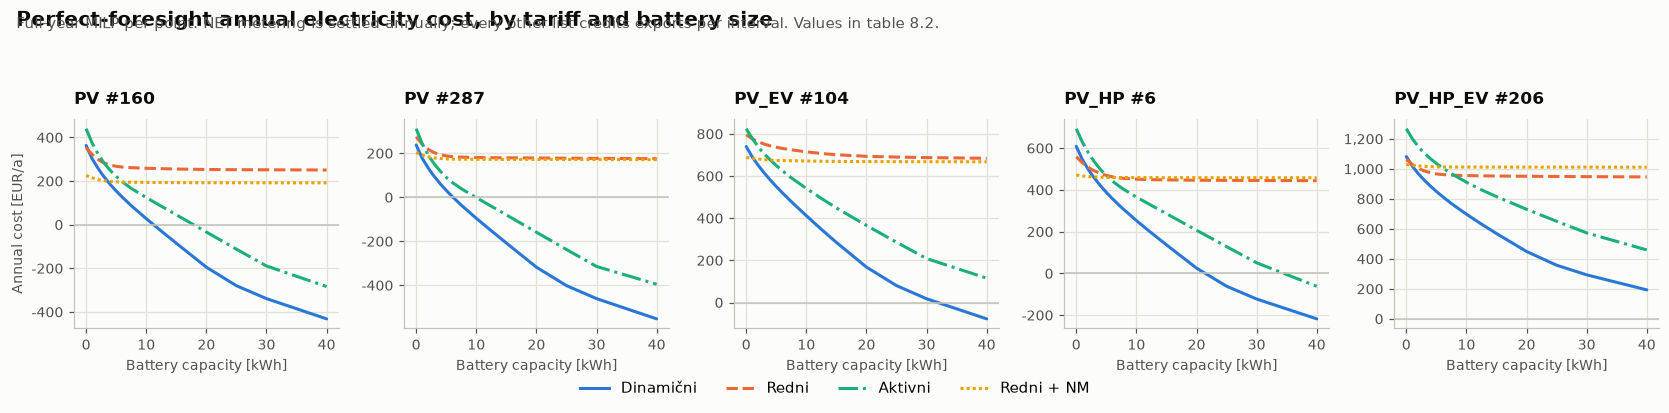

In [15]:
### Annual electricity cost vs battery size
small_multiples(
    "Cost_EUR",
    "Perfect-foresight annual electricity cost, by tariff and battery size",
    "Full-year MILP per point. NET metering is settled annually; every other list credits "
    "exports per interval. Values in table 8.2.",
    "Annual cost [EUR/a]",
    zero_line=True,
)

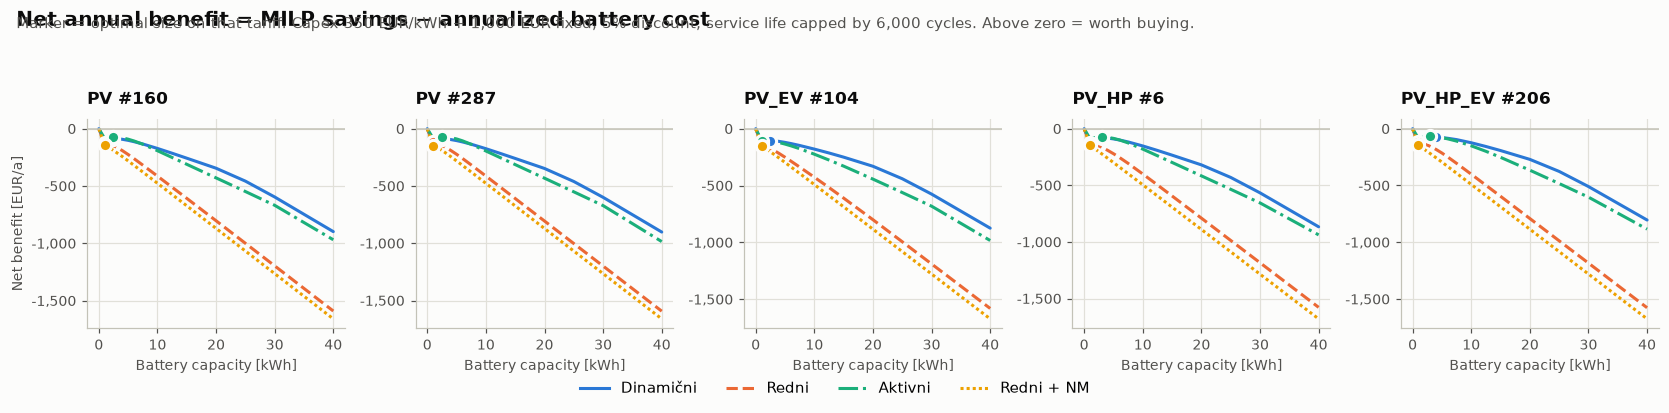

In [16]:
### Net annual benefit — the optimal size is the peak of each curve
small_multiples(
    "Net_Annual_EUR",
    "Net annual benefit = MILP savings − annualized battery cost",
    f"Marker = optimal size on that tariff. Capex {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh + "
    f"{CAPEX_FIXED_EUR:,.0f} EUR fixed, {DISCOUNT_RATE:.0%} discount, service life capped by "
    f"{BATTERY_CYCLE_LIMIT_EFC:,} cycles. Above zero = worth buying.",
    "Net benefit [EUR/a]",
    zero_line=True,
    mark_optimum=True,
)

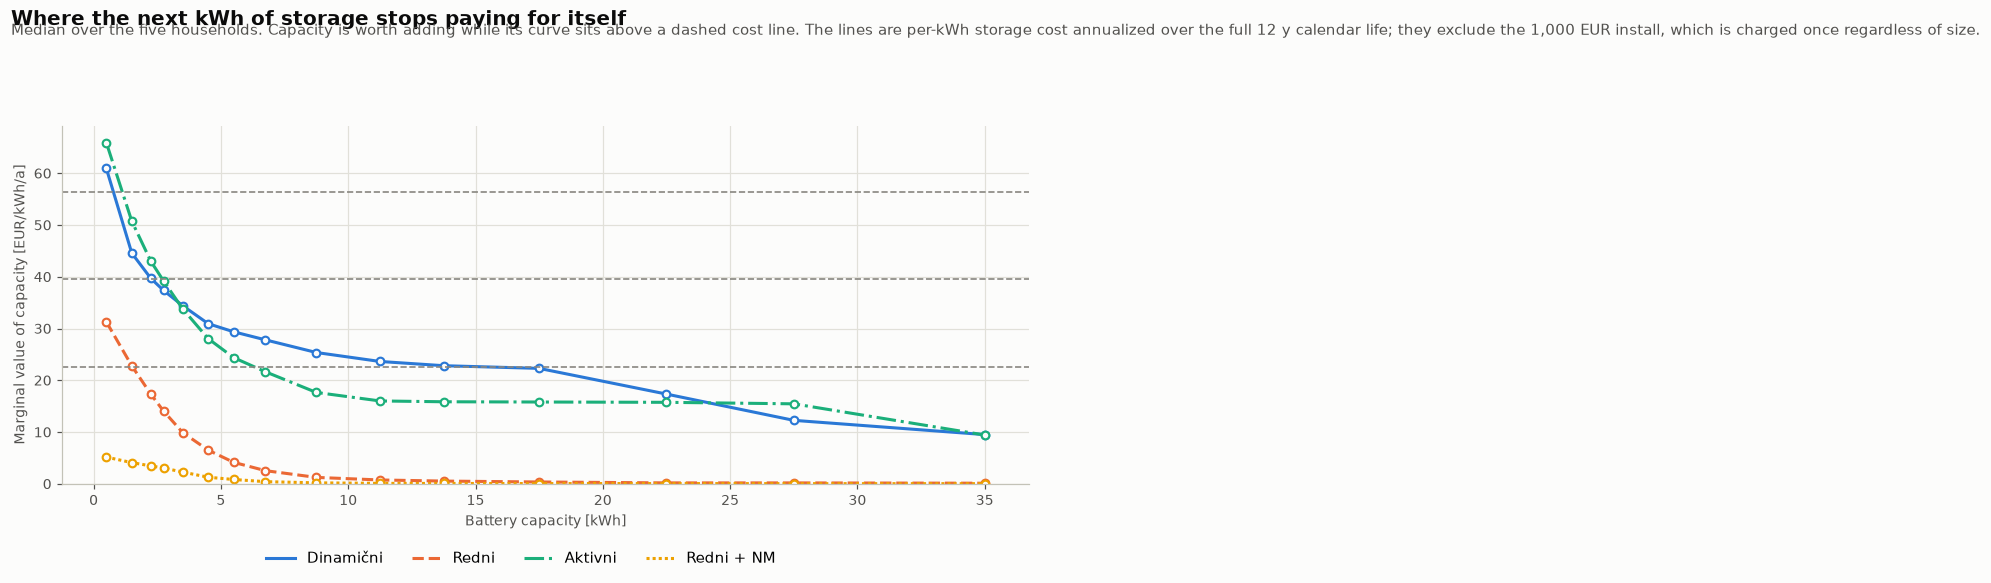

In [17]:
### Where the next kWh of storage stops paying for itself
fig, ax = plt.subplots(figsize=(9.5, 5))
marginal = (
    df.dropna(subset=["Marginal_Value_EUR_per_kWh"])
    .groupby(["Tariff", "Capacity_kWh"], observed=True)["Marginal_Value_EUR_per_kWh"]
    .median()
)
# Plotted at the midpoint of the interval the difference was taken over.
caps = np.sort(df["Capacity_kWh"].unique())
midpoints = dict(zip(caps[1:], (caps[1:] + caps[:-1]) / 2))

for tariff in TARIFF_ORDER:
    series = marginal.loc[tariff]
    ax.plot([midpoints[c] for c in series.index], series.values,
            color=TARIFF_COLOR[tariff], ls=TARIFF_DASH[tariff], lw=2,
            marker="o", ms=5, mfc=SURFACE, mew=1.4)

crf_ref = capital_recovery_factor(DISCOUNT_RATE, BATTERY_CALENDAR_LIFE_Y)
for capex_per_kwh in CAPEX_SCENARIOS_EUR_PER_KWH:
    level = capex_per_kwh * crf_ref
    ax.axhline(level, color=MUTED, lw=1.1, ls="--")
    ax.annotate(f"{capex_per_kwh:,.0f} EUR/kWh installed  ({level:,.1f} EUR/kWh/a)",
                xy=(caps.max(), level), xytext=(-4, 4), textcoords="offset points",
                ha="right", color=INK_2, fontsize=9)

ax.set_ylim(bottom=0)
ax.set_xlabel("Battery capacity [kWh]")
ax.set_ylabel("Marginal value of capacity [EUR/kWh/a]")
ax.yaxis.set_major_formatter(PLAIN)
suptitle(fig, "Where the next kWh of storage stops paying for itself",
         f"Median over the five households. Capacity is worth adding while its curve sits "
         f"above a dashed cost line. The lines are per-kWh storage cost annualized over the "
         f"full {BATTERY_CALENDAR_LIFE_Y} y calendar life; they exclude the "
         f"{CAPEX_FIXED_EUR:,.0f} EUR install, which is charged once regardless of size.")
tariff_legend(fig)
fig.tight_layout(rect=(0, 0.03, 1, 0.88))
plt.show()

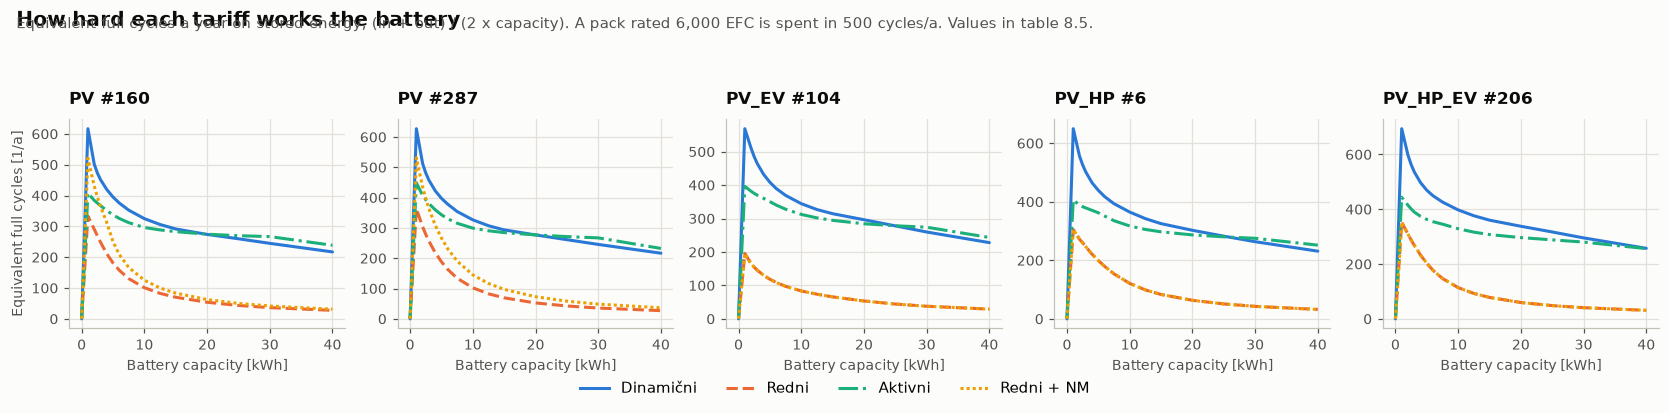

In [18]:
### Equivalent full cycles per year
small_multiples(
    "Equivalent_Full_Cycles",
    "How hard each tariff works the battery",
    f"Equivalent full cycles a year on stored energy, (in + out) / (2 x capacity). "
    f"A pack rated {BATTERY_CYCLE_LIMIT_EFC:,} EFC is spent in "
    f"{BATTERY_CYCLE_LIMIT_EFC // BATTERY_CALENDAR_LIFE_Y} cycles/a. Values in table 8.5.",
    "Equivalent full cycles [1/a]",
    fmt=PLAIN,
)

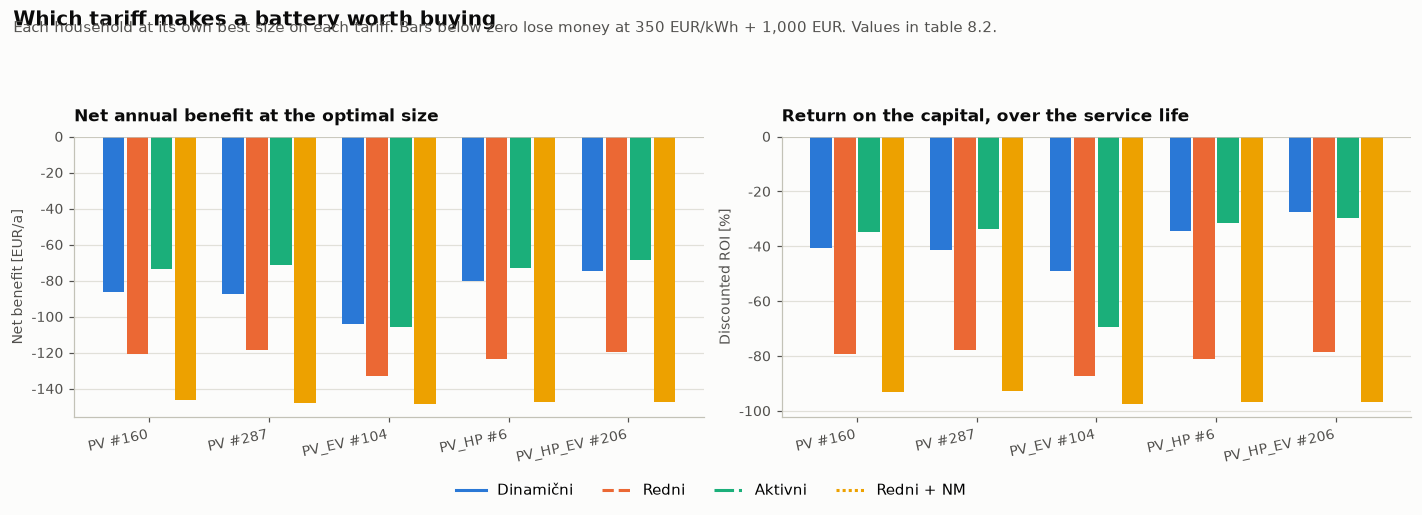

In [19]:
### The headline comparison: net annual benefit at each household's optimal size
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
x = np.arange(len(LABEL_ORDER))
width = 0.2

for ax, (value, ylabel, fmt, panel_title) in zip(axes, [
    ("Net_Annual_EUR", "Net benefit [EUR/a]", EUR, "Net annual benefit at the optimal size"),
    ("ROI_pct", "Discounted ROI [%]", PLAIN, "Return on the capital, over the service life"),
]):
    for i, tariff in enumerate(TARIFF_ORDER):
        vals = [
            float(best_table.loc[(best_table["Label"] == lab) & (best_table["Tariff"] == tariff), value].iloc[0])
            for lab in LABEL_ORDER
        ]
        # 2px surface gap between adjacent bars via the width inset.
        ax.bar(x + (i - 1.5) * width, vals, width * 0.9, color=TARIFF_COLOR[tariff],
               label=tariff, zorder=2)
    ax.axhline(0, color=BASELINE, lw=1.0, zorder=3)
    ax.set_xticks(x, LABEL_ORDER, rotation=12, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(panel_title)
    ax.yaxis.set_major_formatter(fmt)
    ax.grid(axis="x", visible=False)

suptitle(fig, "Which tariff makes a battery worth buying",
         f"Each household at its own best size on each tariff. Bars below zero lose money at "
         f"{CAPEX_EUR_PER_KWH:,.0f} EUR/kWh + {CAPEX_FIXED_EUR:,.0f} EUR. Values in table 8.2.")
tariff_legend(fig)
fig.tight_layout(rect=(0, 0.03, 1, 0.90))
plt.show()

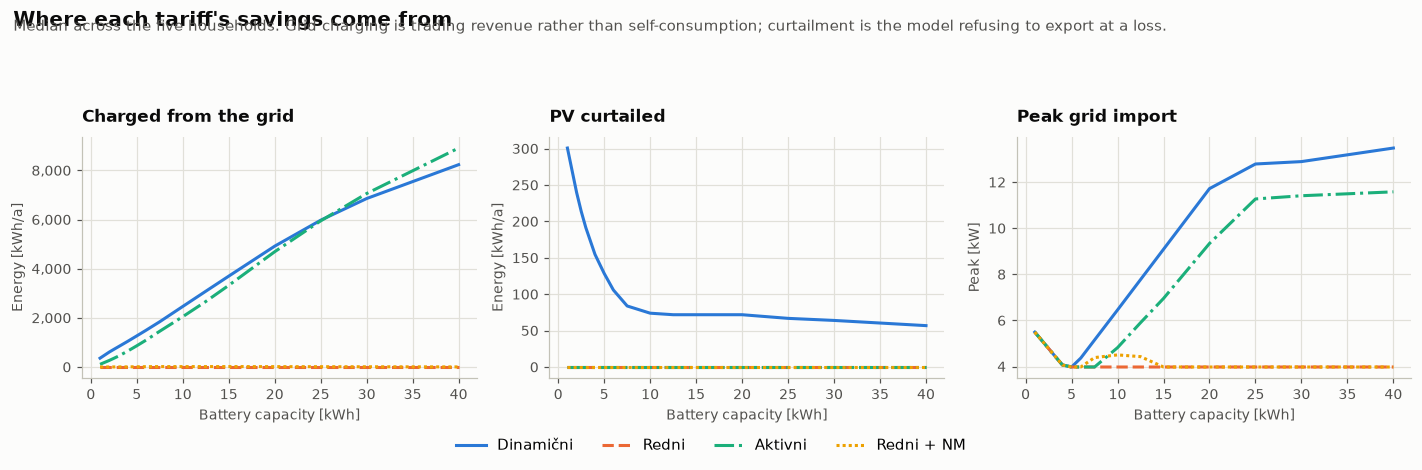

In [20]:
### What the battery actually does: throughput, curtailment, peak import
fig, axes = plt.subplots(1, 3, figsize=(13, 4.0))
grouped = df[df["Capacity_kWh"] > 0].groupby(["Tariff", "Capacity_kWh"])

for ax, (value, title, ylabel) in zip(axes, [
    ("Grid_Charged_kWh", "Charged from the grid", "Energy [kWh/a]"),
    ("Curtailed_kWh", "PV curtailed", "Energy [kWh/a]"),
    ("Peak_Import_kW", "Peak grid import", "Peak [kW]"),
]):
    for tariff in TARIFF_ORDER:
        series = grouped[value].median().loc[tariff]
        ax.plot(series.index, series.values, color=TARIFF_COLOR[tariff],
                ls=TARIFF_DASH[tariff], lw=2)
    ax.set_title(title)
    ax.set_xlabel("Battery capacity [kWh]")
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(PLAIN)

suptitle(fig, "Where each tariff's savings come from",
         "Median across the five households. Grid charging is trading revenue rather than "
         "self-consumption; curtailment is the model refusing to export at a loss.")
tariff_legend(fig)
fig.tight_layout(rect=(0, 0.03, 1, 0.89))
plt.show()

## 10. Read-out

In [21]:
lines = [
    f"Five PV households from {', '.join(PV_DATASETS)}, calendar year 2024",
    f"{N_STEPS_FULL_YEAR:,} intervals of {step_minutes:.0f} min each — the whole year, every run",
    f"{len(TARIFF_ORDER)} GEN-I price lists x {len(BATTERY_SIZES_KWH)} capacities "
    f"({BATTERY_SIZES_KWH.min():.0f}-{BATTERY_SIZES_KWH.max():.0f} kWh) = {len(df)} full-year MILPs",
    f"SI tariff regime {PRICING_REFERENCE_YEAR}, peak reset {PEAK_RESET_MONTHS or 'never (annual ratchet)'}",
    "",
    "WITHOUT A BATTERY",
]
for label in LABEL_ORDER:
    r = no_batt.loc[label]
    lines.append(
        f"  {label:>16}: cheapest {str(r['Cheapest']):<24} "
        f"{float(r[TARIFF_ORDER].min()):8,.2f} EUR/a"
        f"   (spread across the four lists {float(r['Spread_EUR']):7,.2f} EUR/a)"
    )

lines += ["", "WITH THE BEST BATTERY THE TARIFF SUPPORTS"]
for _, r in headline.iterrows():
    lines.append(
        f"  {r['Household']:>16}: {str(r['Best_tariff_with_battery']):<12} "
        f"{r['Optimal_kWh']:5.1f} kWh -> saves {r['Savings_EUR']:8,.2f} EUR/a, "
        f"net {r['Net_Annual_EUR']:+8,.2f} EUR/a, ROI {r['ROI_pct']:+7.1f} %, "
        f"payback {r['Payback_y']:5.1f} y, {r['Cycles_per_year']:5.0f} cycles/a "
        f"[pays: {r['Battery_pays']}; storage cost only: {r['Pays_storage_only']}]"
    )

n_pays = int((headline["Battery_pays"] == "yes").sum())
n_storage = int((headline["Pays_storage_only"] == "yes").sum())
edge = best_table[best_table["Optimum_At_Grid_Edge"] != ""]
lines += [
    "",
    f"  -> {n_pays} of {len(headline)} households have ANY capacity with a positive net annual "
    f"benefit at {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh + {CAPEX_FIXED_EUR:,.0f} EUR fixed.",
    f"  -> {n_storage} of {len(headline)} do once the {CAPEX_FIXED_EUR:,.0f} EUR install is "
    f"treated as sunk and only the storage is charged for — that fixed term, not the",
    f"     per-kWh price, is what decides it at these sizes.",
]
if len(edge):
    lines.append(
        f"  -> {len(edge)} of {len(best_table)} (household, tariff) optima sit on the edge of the "
        f"swept grid ({SMALLEST_SIZED:g}-{LARGEST_SIZED:g} kWh), so the grid rather than the"
    )
    lines.append("     economics is picking those sizes — read them as 'as small as swept', not as an optimum.")

lines += ["", "EXTREMES — where the assumptions show"]
hi = headline.loc[headline["Net_Annual_EUR"].idxmax()]
lo = headline.loc[headline["Net_Annual_EUR"].idxmin()]
for tag, r in (("best ", hi), ("worst", lo)):
    key = [k for k in HOUSEHOLD_KEYS if HOUSEHOLD_LABELS[k] == r["Household"]][0]
    prof = selected[(selected["Dataset"] == key[0]) & (selected["Household"] == key[1])].iloc[0]
    run = df[(df["Label"] == r["Household"]) & (df["Tariff"] == r["Best_tariff_with_battery"])
             & (df["Capacity_kWh"] == r["Optimal_kWh"])].iloc[0]
    lines.append(
        f"  {tag} case {r['Household']:>16} on {str(r['Best_tariff_with_battery']):<12} "
        f"net {r['Net_Annual_EUR']:+8,.2f} EUR/a"
    )
    lines.append(
        f"          load {prof['Consumption_kWh']:6,.0f} kWh/a, PV {prof['Generation_kWh']:6,.0f} kWh/a "
        f"(PV/load {prof['PV_to_Load']:.2f}), {prof['Role']}"
    )
    lines.append(
        f"          at the optimum: imports {run['Import_kWh']:6,.0f}, exports {run['Export_kWh']:6,.0f}, "
        f"curtails {run['Curtailed_kWh']:6,.0f} kWh/a; {run['Grid_Charged_kWh']:6,.0f} kWh/a of the "
        f"charging came from the grid ({100 * run['Grid_Charged_kWh'] / max(run['Charged_kWh'], 1e-9):.0f} % "
        f"of throughput — that share is arbitrage, not self-consumption)"
    )
    lines.append(
        f"          peak import {run['Peak_Import_kW']:5.2f} kW against a contracted "
        f"{run['Contracted_Power_kW']:5.2f} kW"
    )

lines += ["", "PER TARIFF, MEDIAN OVER THE FIVE HOUSEHOLDS AT THEIR OPTIMAL SIZE"]
for tariff in TARIFF_ORDER:
    sub = best_table[best_table["Tariff"] == tariff]
    lines.append(
        f"  {tariff:>12}: {sub['Capacity_kWh'].median():5.1f} kWh, "
        f"saves {sub['Savings_EUR'].median():8,.2f} EUR/a, "
        f"net {sub['Net_Annual_EUR'].median():+8,.2f} EUR/a, "
        f"ROI {sub['ROI_pct'].median():+7.1f} %, "
        f"{sub['Equivalent_Full_Cycles'].median():5.0f} cycles/a, "
        f"life {sub['Service_Life_y'].median():4.1f} y "
        f"({sub['Life_Limited_By'].mode().iloc[0]}-limited)"
    )

lines += ["", "SENSITIVITY — break-even installed cost at each household's optimum"]
for _, r in best_table.iterrows():
    if str(r["Tariff"]) == str(
        headline.loc[headline["Household"] == r["Label"], "Best_tariff_with_battery"].iloc[0]
    ):
        lines.append(
            f"  {r['Label']:>16} on {r['Tariff']:<12}: pays for itself below "
            f"{float(df.loc[(df['Label'] == r['Label']) & (df['Tariff'] == r['Tariff']) & (df['Capacity_kWh'] == r['Capacity_kWh']), 'Break_Even_Capex_EUR_kWh'].iloc[0]):7,.0f} EUR/kWh"
            f"   (assumed {CAPEX_EUR_PER_KWH:,.0f})"
        )

print("\n".join(lines))

Five PV households from Fluvius_PV, Fluvius_PV_EV, Fluvius_PV_HP, Fluvius_PV_HP_EV, calendar year 2024
35,136 intervals of 15 min each — the whole year, every run
4 GEN-I price lists x 16 capacities (0-40 kWh) = 320 full-year MILPs
SI tariff regime 2026, peak reset never (annual ratchet)

WITHOUT A BATTERY
           PV #160: cheapest Redni + NM                 225.70 EUR/a   (spread across the four lists  214.48 EUR/a)
           PV #287: cheapest Redni + NM                 203.16 EUR/a   (spread across the four lists  108.50 EUR/a)
        PV_EV #104: cheapest Redni + NM                 687.90 EUR/a   (spread across the four lists  136.97 EUR/a)
          PV_HP #6: cheapest Redni + NM                 471.27 EUR/a   (spread across the four lists  221.85 EUR/a)
     PV_HP_EV #206: cheapest Redni + NM               1,029.28 EUR/a   (spread across the four lists  238.51 EUR/a)

WITH THE BEST BATTERY THE TARIFF SUPPORTS
           PV #160: Aktivni        2.5 kWh -> saves   138.06 EUR/a, n

### Caveats worth keeping in view

* **Perfect foresight.** Every point is an upper bound; a real controller (DQN, MPC) captures
  only part of it, so the true optimal size is at or below what these curves show, and every
  ROI here is optimistic.
* **0.1 % MIP gap.** Each point is within 0.1 % of its own optimum. That is a few tenths of a
  euro on these bills, well under the spacing between adjacent capacities. Set
  `SOLVER_GAP_REL = 0` for proven optima at 10–20x the runtime.
* **NET metering is modelled as supplier-energy netting only.** Network charges and levies are
  billed on gross metered offtake, which is the post-2024 network act. The list's extra
  courtesy — one monthly fee waived per whole MWh of *surplus* beyond annual consumption — is
  not modelled; it is worth at most a couple of euro a year and only for households that
  export more than they import.
* **Arbitrage through the grid.** Under the dynamic list the model may buy cheap grid energy
  and sell it back later; the *Charged from the grid* panel makes the scale of it visible.
  Where that line is a large share of throughput, the savings are trading revenue that depends
  on the 2024 SIPX spread repeating, not on PV self-consumption. It is also what drives the
  high cycle counts, and therefore the cycle-limited service life.
* **Peak charges.** `PEAK_RESET_MONTHS = None` ratchets one peak across the whole year and
  charges the excess once. The real SI regulation settles excess power per calendar month;
  `PEAK_RESET_MONTHS = 1` switches to that and makes peak shaving a larger share of the
  battery's value — identically for all four tariffs, since they share a network tariff.
* **Contracted power.** `CONTRACTED_POWER_KW = None` uses the environment's default, the
  household's own historical no-battery peak divided by 1.5, so every household starts out of
  contract and pays an excess-power charge. That inflates the battery's value uniformly across
  the four tariffs; set a real connection size to remove it.
* **The Fluvius clock is 1–2 h off (section 4).** The input timestamps are Brussels local time
  labelled `Z`, so every interval is priced under a tariff block 1–2 hours later than it
  really occurred, and the SMP series is aligned to it with the same shift. All four tariffs
  read the same shifted clock, so the *comparison* holds; the absolute bills, and in
  particular anything that hinges on block boundaries (the Aktivni list, the ratchet peak),
  carry the error. Repository-wide input fix, not a notebook fix.
* **`Feed_In_Volume_kWh` is metered feed-in, not gross PV.** The repository treats it as the
  generation series throughout, and roughly 12 % of intervals have both registers nonzero, so
  it is not a purely netted register — but self-consumption that never crossed the meter is
  not in this data, and the PV-to-load ratios above should be read with that in mind.
* **One price year, five households.** 2024 SMP volatility drives most of the dynamic list's
  advantage. Re-run against another price year before generalizing, and remember five
  households is a sample, not a distribution.